# Diabetes Prediction + SHAP Explainability

**Goal    :** Build an ML model that predicts diabetes risk
              AND explains WHY it made each decision using SHAP.

**Dataset :** Diabetes Prediction Dataset 2023 (Kaggle)
            - 100,000 patient records
            - 9 clinical features including HbA1c
            - Binary outcome: diabetic / not diabetic

**Models  :** Logistic Regression · Random Forest · XGBoost
**Key skill:** SHAP Explainability — the skill that separates
              engineers from students in ML interviews.

**Author  :** Hasan Akhras


In [41]:
# libraries
!pip install kagglehub shap xgboost -q

import kagglehub, os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# sklearn = the standard ML library in Python
# contains everything: models, metrics, preprocessing, splitting
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                                      recall_score, f1_score,
                                      confusion_matrix,
                                      classification_report,
                                      roc_auc_score, roc_curve)
import xgboost as xgb

# shap = SHapley Additive exPlanations
# explains WHY the model predicted what it predicted
import shap

warnings.filterwarnings('ignore')
print("All libraries loaded.")

All libraries loaded.


In [43]:
# S1— LOAD DATA

path = kagglehub.dataset_download(
    "iammustafatz/diabetes-prediction-dataset"
)

# list files to find the correct CSV name
print("Files available:", os.listdir(path))

df = pd.read_csv(os.path.join(path, 'diabetes_prediction_dataset.csv'))

print(f"\n{df.shape[0]:,} patients loaded · {df.shape[1]} columns")
print(f"\nColumns:\n{list(df.columns)}")
df.head(10)

Using Colab cache for faster access to the 'diabetes-prediction-dataset' dataset.
Files available: ['diabetes_prediction_dataset.csv']

100,000 patients loaded · 9 columns

Columns:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


In [3]:
# S2 — UNDERSTAND THE COLUMNS
# Never skip this step — wrong assumptions = wrong model

print("""
Column Guide:
──────────────────────────────────────────────────────────
gender              → Male / Female / Other
age                 → patient age in years
hypertension        → 1 = has hypertension, 0 = no
heart_disease       → 1 = has heart disease, 0 = no
smoking_history     → never / current / former / ever / not current
bmi                 → body mass index (kg/m²)
HbA1c_level         → hemoglobin A1c — avg blood sugar over 3 months
                      < 5.7  = normal
                      5.7-6.4 = pre-diabetic
                      ≥ 6.5  = diabetic ← most important feature
blood_glucose_level → fasting blood glucose (mg/dL)
                      < 100  = normal
                      100-125 = pre-diabetic
                      ≥ 126  = diabetic
diabetes            → TARGET: 1 = diabetic, 0 = not diabetic
──────────────────────────────────────────────────────────

KEY MEDICAL INSIGHT:
HbA1c and blood_glucose_level are the two gold-standard
clinical tests for diabetes diagnosis in real medicine.
This makes them the most predictive features in our model.
""" )


Column Guide:
──────────────────────────────────────────────────────────
gender              → Male / Female / Other
age                 → patient age in years
hypertension        → 1 = has hypertension, 0 = no
heart_disease       → 1 = has heart disease, 0 = no
smoking_history     → never / current / former / ever / not current
bmi                 → body mass index (kg/m²)
HbA1c_level         → hemoglobin A1c — avg blood sugar over 3 months
                      < 5.7  = normal
                      5.7-6.4 = pre-diabetic
                      ≥ 6.5  = diabetic ← most important feature
blood_glucose_level → fasting blood glucose (mg/dL)
                      < 100  = normal
                      100-125 = pre-diabetic
                      ≥ 126  = diabetic
diabetes            → TARGET: 1 = diabetic, 0 = not diabetic
──────────────────────────────────────────────────────────

KEY MEDICAL INSIGHT:
HbA1c and blood_glucose_level are the two gold-standard
clinical tests for diabetes diag

In [5]:
# S3 — DATA QUALITY CHECK + AUTO FIX

print("  DATA QUALITY REPORT")
print("=" * 30)

# shape
print(f"\n  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")

# Missing Values
# missing values = empty cells that break models
print("\n Missing Values")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No missing values. Dataset is clean.")
else:
    pct = (missing / len(df) * 100).round(1)
    print(pd.DataFrame({'count': missing, '%': pct})
            [missing > 0].sort_values('%', ascending=False))

# Duplicates — detect AND remove
# duplicates = identical rows that confuse the model
# solution: keep the first occurrence, drop the rest
print("\n Duplicates")
dupes_before = df.duplicated().sum()
print(f"  Found : {dupes_before:,} duplicate rows")

if dupes_before > 0:
    df = df.drop_duplicates(keep='first')
    dupes_after = df.duplicated().sum()
    print(f"  Removed : {dupes_before - dupes_after:,} rows")
    print(f"  Rows remaining : {df.shape[0]:,}")
else:
    print(f"  No duplicates found.")

# Target Distribution
print("\n Target Distribution")
counts = df['diabetes'].value_counts()
for label, count in counts.items():
    pct   = round(count / len(df) * 100, 1)
    name  = 'Diabetic' if label == 1 else 'Not Diabetic'
    print(f"  {name:<15} {count:>7,} ({pct}%)")

ratio = counts[0] / counts[1]
print(f"\n  Imbalance ratio : {ratio:.1f}:1")
if ratio > 3:
    print("  Imbalanced")
else:
    print("  Acceptable balance")

# Statistical Summary
print("\n Statistical Summary")
display(df.describe().round(2))

  DATA QUALITY REPORT

  Rows    : 96,146
  Columns : 9

 Missing Values
No missing values. Dataset is clean.

 Duplicates
  Found : 0 duplicate rows
  No duplicates found.

 Target Distribution
  Not Diabetic     87,664 (91.2%)
  Diabetic          8,482 (8.8%)

  Imbalance ratio : 10.3:1
  Imbalanced — F1 score is more reliable than Accuracy

 Statistical Summary


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.00,96146.00,96146.00,96146.00,96146.00,96146.00,96146.00
mean,41.79,0.08,0.04,27.32,5.53,138.22,0.09
std,22.46,0.27,0.20,6.77,1.07,40.91,0.28
min,0.08,0.00,0.00,10.01,3.50,80.00,0.00
25%,24.00,0.00,0.00,23.40,4.80,100.00,0.00
50%,43.00,0.00,0.00,27.32,5.80,140.00,0.00
75%,59.00,0.00,0.00,29.86,6.20,159.00,0.00
max,80.00,1.00,1.00,95.69,9.00,300.00,1.00


In [7]:
# S4 — EDA

fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=(
        'HbA1c by Diagnosis',
        'Blood Glucose by Diagnosis',
        'BMI by Diagnosis',
        'Age by Diagnosis',
        'Diabetes Rate by Smoking History',
        'Hypertension & Heart Disease Rate'
    )
)

colors = {1: '#E24B4A', 0: '#1D9E75'}
labels = {1: 'Diabetic', 0: 'Not Diabetic'}

# Panel 1 — HbA1c box plot
# HbA1c is the gold-standard diabetes marker
for outcome, color in colors.items():
    fig.add_trace(go.Box(
        y    = df[df['diabetes']==outcome]['HbA1c_level'],
        name = labels[outcome],
        marker_color = color,
        boxmean = True,
        showlegend = (outcome == 1)
    ), row=1, col=1)

# Panel 2 — Blood Glucose box plot
for outcome, color in colors.items():
    fig.add_trace(go.Box(
        y    = df[df['diabetes']==outcome]['blood_glucose_level'],
        name = labels[outcome],
        marker_color = color,
        boxmean = True,
        showlegend = False
    ), row=1, col=2)

# Panel 3 — BMI box plot
for outcome, color in colors.items():
    fig.add_trace(go.Box(
        y    = df[df['diabetes']==outcome]['bmi'],
        name = labels[outcome],
        marker_color = color,
        boxmean = True,
        showlegend = False
    ), row=1, col=3)

# Panel 4 — Age distribution
for outcome, color in colors.items():
    subset = df[df['diabetes']==outcome]
    fig.add_trace(go.Histogram(
        x    = subset['age'],
        name = labels[outcome],
        marker_color = color,
        opacity = 0.7,
        showlegend = False
    ), row=2, col=1)

# Panel 5 — Smoking history diabetes rate
smoking_rate = (
    df.groupby('smoking_history')['diabetes']
    .agg(['sum','count'])
    .assign(rate=lambda x: (x['sum']/x['count']*100).round(1))
    .reset_index()
    .sort_values('rate', ascending=False)
)
fig.add_trace(go.Bar(
    x = smoking_rate['smoking_history'],
    y = smoking_rate['rate'],
    marker_color = '#378ADD',
    showlegend = False
), row=2, col=2)

# Panel 6 — Hypertension & Heart Disease
comorbidity = pd.DataFrame({
    'Condition': ['Hypertension', 'Heart Disease'],
    'Diabetic'    : [
        df[df['diabetes']==1]['hypertension'].mean()*100,
        df[df['diabetes']==1]['heart_disease'].mean()*100
    ],
    'Not Diabetic': [
        df[df['diabetes']==0]['hypertension'].mean()*100,
        df[df['diabetes']==0]['heart_disease'].mean()*100
    ]
})
fig.add_trace(go.Bar(
    name='Diabetic',
    x=comorbidity['Condition'],
    y=comorbidity['Diabetic'],
    marker_color='#E24B4A',
    showlegend=False
), row=2, col=3)
fig.add_trace(go.Bar(
    name='Not Diabetic',
    x=comorbidity['Condition'],
    y=comorbidity['Not Diabetic'],
    marker_color='#1D9E75',
    showlegend=False
), row=2, col=3)

fig.update_layout(
    title_text    = 'EDA',
    height        = 640,
    paper_bgcolor = 'white',
    plot_bgcolor  = 'white',
    barmode       = 'group'
)
fig.show()

# print key averages
print("\n Average values by diagnosis:")
print(df.groupby('diabetes')[
    ['HbA1c_level','blood_glucose_level','bmi','age']
].mean().round(2).rename(index={0:'Not Diabetic', 1:'Diabetic'}).to_string())


 Average values by diagnosis:
              HbA1c_level  blood_glucose_level    bmi    age
diabetes                                                    
Not Diabetic         5.40               132.82  26.87  39.94
Diabetic             6.93               194.03  32.00  60.93


**What I observed:**

**1. HbA1c is the strongest separator**
Diabetic avg = 6.93 vs Non-Diabetic avg = 5.40
The boxes barely overlap — this feature alone can almost split the two groups.

**2. Blood Glucose confirms the pattern**
Diabetic avg = 194 mg/dL vs Non-Diabetic avg = 132 mg/dL
A gap of 62 points — clinically significant.

**3. BMI shows overlap — weaker signal**
Diabetic avg = 32.0 vs Non-Diabetic avg = 26.87
The boxes overlap heavily — BMI alone is not enough to diagnose diabetes.

**4. Former smokers have the highest diabetes rate**
Surprising finding — likely because former smokers are older
and have accumulated more health risks over time.

**5. Hypertension is a strong comorbidity**
~24% of diabetic patients have hypertension vs ~6% of healthy patients.
This means hypertension and diabetes often appear together.

In [8]:
# S5 — PREPROCESSING
# ML models only understand numbers — not text.
# We must convert all text columns to numbers before training.

df_ml = df.copy()

# Encode categorical columns
# LabelEncoder converts text → numbers
le = LabelEncoder()

# gender: Male/Female/Other → 0/1/2
df_ml['gender'] = le.fit_transform(df_ml['gender'])

# smoking_history has multiple categories
smoking_map = {
    'never'      : 0,
    'No Info'    : 1,
    'not current': 2,
    'ever'       : 3,
    'former'     : 4,
    'current'    : 5
}
# map() replaces each value using the dictionary
df_ml['smoking_history'] = df_ml['smoking_history'].map(smoking_map)

# fill any unmapped values with 1 (No Info)
df_ml['smoking_history'] = df_ml['smoking_history'].fillna(1)

print("Categorical encoding done.")
print(f"\nGender values    : {sorted(df_ml['gender'].unique())}")
print(f"Smoking values   : {sorted(df_ml['smoking_history'].unique())}")

# Define Features (X) and Target (y)
# X = everything we feed INTO the model
# y = what the model must PREDICT
feature_cols = ['gender','age','hypertension','heart_disease',
                'smoking_history','bmi','HbA1c_level',
                'blood_glucose_level']

X = df_ml[feature_cols]
y = df_ml['diabetes']

print(f"\nFeatures (X) shape : {X.shape}")
print(f"Target   (y) shape : {y.shape}")
print(f"Feature columns    : {feature_cols}")

Categorical encoding done.

Gender values    : [np.int64(0), np.int64(1), np.int64(2)]
Smoking values   : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Features (X) shape : (96146, 8)
Target   (y) shape : (96146,)
Feature columns    : ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']


In [10]:
# S6 — TRAIN/TEST SPLIT + FEATURE SCALING
#
# WHY split?
# We train on 80% and test on the remaining 20%.
# The model NEVER sees test data during training.
# This simulates real-world use: model sees new patients.
#
# WHY scale?
# age ranges 0-80, bmi ranges 10-70, glucose ranges 80-300
# Without scaling, the model thinks glucose is 4× more
# important than age just because its numbers are bigger.
# StandardScaler fixes this — all features become mean=0, std=1
# ----------------------------------------------------------------

# stratify=y ensures both train and test have the same
# proportion of diabetic patients — important for imbalanced data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,    # 20% for testing
    random_state = 42,      # ensures same split every run
    stratify     = y        # keeps class ratio balanced
)

print(f"Train set : {X_train.shape[0]:,} patients")
print(f"Test  set : {X_test.shape[0]:,} patients")
print(f"\nDiabetes rate in train : "
      f"{y_train.mean()*100:.1f}%")
print(f"Diabetes rate in test  : "
      f"{y_test.mean()*100:.1f}%")

# Scale features
# fit ONLY on training data, then transform both
# Why? If we fit on all data, test data "leaks" into training
# This is called DATA LEAKAGE — a common and serious mistake
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)   # fit + transform
X_test_sc   = scaler.transform(X_test)        # transform only

print(f"\nScaling done.")
print(f"   Before: age range = [{X_train['age'].min():.0f}"
      f", {X_train['age'].max():.0f}]")
print(f"   After : age range = [{X_train_sc[:,1].min():.2f}"
      f", {X_train_sc[:,1].max():.2f}]")

Train set : 76,916 patients
Test  set : 19,230 patients

Diabetes rate in train : 8.8%
Diabetes rate in test  : 8.8%

Scaling done.
   Before: age range = [0, 80]
   After : age range = [-1.86, 1.70]


In [21]:
# S7 — TRAIN MODELS
#
# We train different models and compare them.
# Why? Each has different strengths:
#
# Logistic Regression = simple, fast, interpretable baseline
# Random Forest       = ensemble of trees, handles non-linearity
# XGBoost             = state-of-the-art, wins most competitions
# ---------------------------------------------------------------
models = {
    'Logistic Regression': LogisticRegression(
        max_iter     = 1000,
        random_state = 42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators = 200,    # 200 decision trees in the forest
        max_depth    = 15,     # max depth of each tree
        random_state = 42,
        n_jobs       = -1      # use all CPU cores
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators    = 200,
        max_depth       = 6,
        learning_rate   = 0.1,   # how fast the model learns
        subsample       = 0.8,   # use 80% of data per tree
        random_state    = 42,
        eval_metric     = 'logloss',
        verbosity       = 0
    )
}

# train all models and store results
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    # .fit() = the actual learning step
    # model looks at X_train and y_train and learns the pattern
    model.fit(X_train_sc, y_train)

    # .predict() = apply learned pattern to new data
    y_pred = model.predict(X_test_sc)

    # .predict_proba() = probability of being diabetic (0 to 1)
    y_pred_prob = model.predict_proba(X_test_sc)[:, 1]

    results[name] = {
        'model'     : model,
        'y_pred'    : y_pred,
        'y_pred_prob': y_pred_prob,
        'accuracy'  : accuracy_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred),
        'recall'    : recall_score(y_test, y_pred),
        'f1'        : f1_score(y_test, y_pred),
        'roc_auc'   : roc_auc_score(y_test, y_pred_prob)
    }

    print(f"F1: {results[name]['f1']:.3f} | "
          f"AUC: {results[name]['roc_auc']:.3f}")


Training Logistic Regression...
F1: 0.732 | AUC: 0.960

Training Random Forest...
F1: 0.808 | AUC: 0.973

Training XGBoost...
F1: 0.807 | AUC: 0.977


In [23]:
# S8 — COMPARE ALL MODELS
#
# Which metric matters most for diabetes prediction?
#
# Recall is the most important metric here.
# Why? A FALSE NEGATIVE (missing a diabetic patient) is
# far more dangerous than a FALSE POSITIVE (flagging a
# healthy person). Missing diabetes = delayed treatment.
# --------------------------------------------------------
# Metrics comparison table
metrics_df = pd.DataFrame({
    name: {
        'Accuracy' : round(r['accuracy'],  4),
        'Precision': round(r['precision'], 4),
        'Recall'   : round(r['recall'],    4),
        'F1 Score' : round(r['f1'],        4),
        'ROC-AUC'  : round(r['roc_auc'],   4)
    }
    for name, r in results.items()
}).T

print("Model Comparison")
print(metrics_df.to_string())
best_model_name = metrics_df['ROC-AUC'].idxmax()
print(f"\nBest model by ROC-AUC: {best_model_name}")

# Visual comparison
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        'Model Metrics Comparison',
        'ROC Curves'
    )
)

# metrics bar chart
metric_names = ['Accuracy','Precision','Recall','F1 Score','ROC-AUC']
model_colors = ['#378ADD', '#1D9E75', '#E24B4A']

for (name, row), color in zip(metrics_df.iterrows(), model_colors):
    fig.add_trace(go.Bar(
        name         = name,
        x            = metric_names,
        y            = row[metric_names].values,
        marker_color = color,
        showlegend   = True
    ), row=1, col=1)

# ROC curves
# ROC curve shows the tradeoff between true positive rate
# and false positive rate at different thresholds
# AUC (area under curve) closer to 1.0 = better model
for (name, r), color in zip(results.items(), model_colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_pred_prob'])
    fig.add_trace(go.Scatter(
        x    = fpr,
        y    = tpr,
        name = f"{name} (AUC={r['roc_auc']:.3f})",
        line = dict(color=color, width=2),
        showlegend = True
    ), row=1, col=2)

# diagonal reference line — represents random guessing
fig.add_trace(go.Scatter(
    x=[0,1], y=[0,1],
    line=dict(color='gray', dash='dash', width=1),
    showlegend=False, name='Random'
), row=1, col=2)

fig.update_layout(
    title_text    = 'Model Performance Comparison',
    height        = 460,
    paper_bgcolor = 'white',
    plot_bgcolor  = 'white',
    barmode       = 'group'
)
fig.show()

Model Comparison
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.9591     0.8687  0.6321    0.7317   0.9596
Random Forest          0.9712     0.9856  0.6840    0.8075   0.9727
XGBoost                0.9708     0.9671  0.6928    0.8073   0.9771

Best model by ROC-AUC: XGBoost


**Best model overall: XGBoost**

**Why XGBoost — not Random Forest?**
Random Forest wins F1 by 0.001 (0.8075 vs 0.8073) — negligible difference.
But XGBoost wins ROC-AUC (0.977 vs 0.973) — the more reliable metric.
ROC-AUC measures performance at ALL thresholds, not just one.
For medical screening, AUC is the gold-standard metric.

**Why is Recall the most important metric here?**
Recall = 0.693 means the model catches 69.3% of diabetic patients.
The remaining 30.7% are missed (False Negatives).
In medicine, a missed diabetic patient = delayed treatment = serious harm.
This means our model needs further improvement on Recall specifically.

**Why is Precision so high (0.967)?**
When the model says "diabetic" — it is right 96.7% of the time.
Very few healthy patients are incorrectly flagged as diabetic.

**What does the ROC curve tell us?**
All three curves hug the top-left corner — far from the diagonal.
The diagonal = random guessing (AUC = 0.5).
Our XGBoost AUC = 0.977 — excellent discrimination ability.

**note:**
The gap between Precision (0.967) and Recall (0.693) is the real problem.
The model is too conservative — it only predicts diabetes when very certain.
Solution: lower the decision threshold from 0.5 to 0.3 to catch more cases.

## Why ROC-AUC and not F1 for model selection?

F1 difference between Random Forest and XGBoost = 0.0002 — negligible.
ROC-AUC difference = 0.977 vs 0.973 — XGBoost wins clearly.

F1 evaluates at ONE threshold (0.5) only.
ROC-AUC evaluates at ALL thresholds — more robust and reliable.

In medical screening, ROC-AUC is the standard metric for model selection.
```

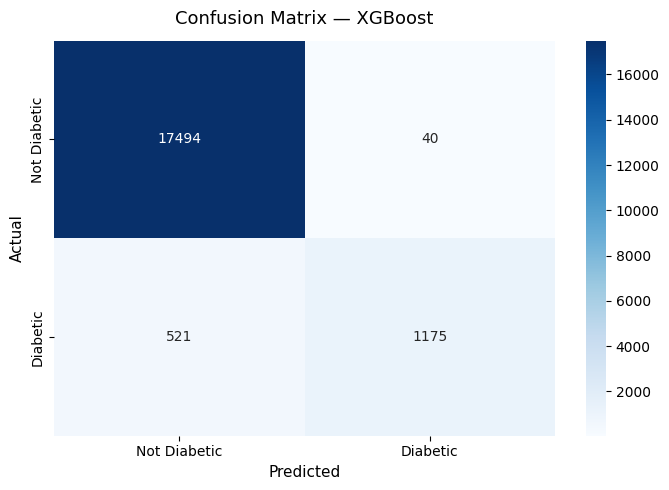


  True  Negatives (correctly identified healthy) : 17,494
  False Positives (healthy flagged as diabetic)   : 40
  False Negatives (missed diabetic patients)   : 521
  True  Positives (correctly identified diabetic) : 1,175

  We missed 521 diabetic patients — this is what Recall measures.


In [24]:
# S9 — CONFUSION MATRIX FOR BEST MODEL
#
# Confusion Matrix tells us exactly where the model is wrong:
#
#
# TN = True Negative  (healthy, predicted healthy)
# FP = False Positive (healthy, predicted diabetic)
# FN = False Negative (diabetic, predicted healthy)
# TP = True Positive  (diabetic, predicted diabetic)

best_model  = results[best_model_name]
cm          = confusion_matrix(y_test, best_model['y_pred'])

tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm,
    annot      = True,
    fmt        = 'd',
    cmap       = 'Blues',
    xticklabels= ['Not Diabetic','Diabetic'],
    yticklabels= ['Not Diabetic','Diabetic'],
    ax         = ax
)
ax.set_title(f'Confusion Matrix — {best_model_name}',
             fontsize=13, pad=12)
ax.set_ylabel('Actual', fontsize=11)
ax.set_xlabel('Predicted', fontsize=11)
plt.tight_layout()
plt.show()

print(f"\n  True  Negatives (correctly identified healthy) : {tn:,}")
print(f"  False Positives (healthy flagged as diabetic)   : {fp:,}")
print(f"  False Negatives (missed diabetic patients)   : {fn:,}")
print(f"  True  Positives (correctly identified diabetic) : {tp:,}")
print(f"\n  We missed {fn:,} diabetic patients — "
      f"this is what Recall measures.")

Global Feature Importance (SHAP Summary):


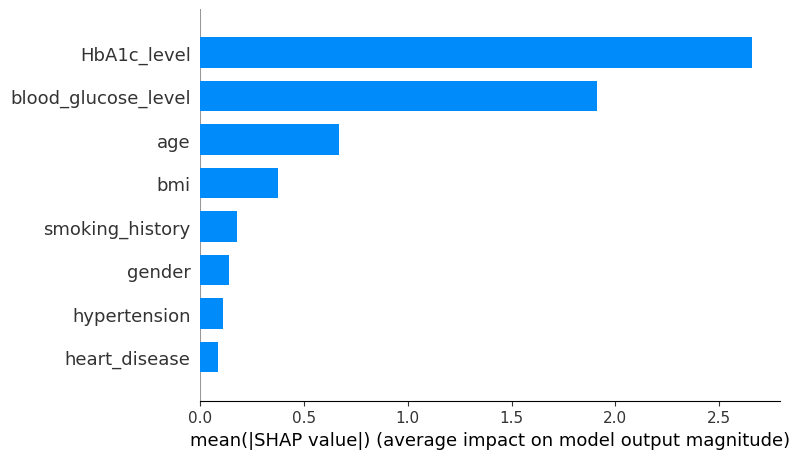

In [25]:
# S10 — SHAP EXPLAINABILITY
#
#
# SHAP answers: "WHY did the model predict this patient
# is diabetic?" for EACH individual prediction.
#
# SHAP value > 0 → this feature PUSHED toward diabetic
# SHAP value < 0 → this feature PUSHED toward not diabetic
# SHAP value = 0 → this feature had no effect

best_xgb = results['XGBoost']['model']

# TreeExplainer is optimized for tree-based models (XGBoost, RF)
# it calculates exact SHAP values very efficiently
explainer   = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_sc)

# convert back to DataFrame for readability
X_test_df = pd.DataFrame(X_test_sc, columns=feature_cols)

#  Plot 1: Summary plot
# Shows the GLOBAL importance of each feature
# Each dot = one patient
# Color = feature value (red=high, blue=low)
# X position = impact on model output
print("Global Feature Importance (SHAP Summary):")
shap.summary_plot(
    shap_values,
    X_test_df,
    plot_type = 'bar',
    show      = True
)


─── Patient Profile ─────────────────────────────────
  Actual diagnosis   : Diabetic
  Model prediction   : 99.9% probability of diabetes
  gender                    1.00
  age                       54.00
  hypertension              0.00
  heart_disease             0.00
  smoking_history           0.00
  bmi                       42.08
  HbA1c_level               5.70
  blood_glucose_level       280.00


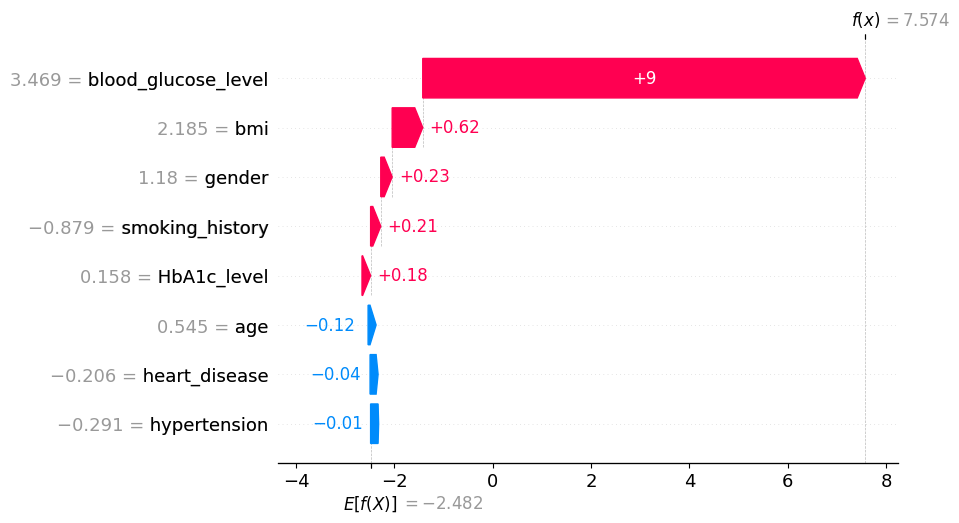

In [40]:
# S11 — EXPLAIN ONE PATIENT'S PREDICTION
#
# This is the most impressive thing to show in an interview.
# We pick one patient and explain EXACTLY why the model
# predicted diabetes — feature by feature.
# ════════════════════════════════════════════════════════════

# pick a diabetic patient from the test set
diabetic_indices = np.where(y_test.values == 1)[0]
patient_idx      = diabetic_indices[0]

patient_data     = X_test_df.iloc[[patient_idx]]
patient_actual   = y_test.iloc[patient_idx]
patient_pred_prob= results['XGBoost']['y_pred_prob'][patient_idx]

print("─── Patient Profile ─────────────────────────────────")
print(f"  Actual diagnosis   : {'Diabetic' if patient_actual==1 else 'Not Diabetic'}")
print(f"  Model prediction   : {patient_pred_prob*100:.1f}% probability of diabetes")

# original (unscaled) values for readability
original_vals = X_test.iloc[patient_idx]
for feat, val in original_vals.items():
    print(f"  {feat:<25} {val:.2f}")

# waterfall plot — shows each feature's contribution
# for this specific patient's prediction
shap.waterfall_plot(
    shap.Explanation(
        values     = shap_values[patient_idx],
        base_values= explainer.expected_value,
        data       = patient_data.iloc[0].values,
        feature_names = feature_cols
    )
)

In [29]:
# S12 — CROSS VALIDATION
# One train/test split might be lucky or unlucky.
# K-Fold Cross Validation repeats the split K times
# and averages the results — more reliable estimate.
#
# StratifiedKFold keeps class ratio in each fold.
# ════════════════════════════════════════════════════════════

print("─── 5-Fold Cross Validation ─────────────────────────")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    # cross_val_score trains and evaluates on 5 different splits
    scores = cross_val_score(
        model, X_train_sc, y_train,
        cv      = skf,
        scoring = 'f1',
        n_jobs  = -1
    )
    print(f"\n  {name}")
    print(f"    F1 per fold  : {[round(s,3) for s in scores]}")
    print(f"    Mean F1      : {scores.mean():.3f} ± {scores.std():.3f}")

─── 5-Fold Cross Validation ─────────────────────────

  Logistic Regression
    F1 per fold  : [np.float64(0.712), np.float64(0.729), np.float64(0.726), np.float64(0.744), np.float64(0.731)]
    Mean F1      : 0.728 ± 0.010

  Random Forest
    F1 per fold  : [np.float64(0.79), np.float64(0.803), np.float64(0.798), np.float64(0.806), np.float64(0.809)]
    Mean F1      : 0.801 ± 0.007

  XGBoost
    F1 per fold  : [np.float64(0.793), np.float64(0.807), np.float64(0.803), np.float64(0.807), np.float64(0.805)]
    Mean F1      : 0.803 ± 0.005


##CROSS VALIDATION
| Model | Mean F1 | Std Dev | Stability |
|-------|---------|---------|-----------|
| Logistic Regression | 0.728 | ± 0.010 | Moderate |
| Random Forest | 0.801 | ± 0.007 | Good |
| XGBoost | 0.803 | ± 0.005 | Best |

**Winner: XGBoost — confirmed.**

**1. XGBoost has the highest Mean F1 (0.803)**
Slightly above Random Forest (0.801) — difference of 0.002.
Small but consistent across all 5 folds.

**2. XGBoost has the lowest Std Dev (± 0.005)**
This is the most important finding here.
Low std = the model performs consistently on ANY subset of data.
High std = the model gets lucky on some folds and bad on others.
XGBoost is the most stable model — least affected by data variation.

**3. What does 5-Fold mean exactly?**
The training data was split into 5 equal parts.
Each time, 4 parts were used for training and 1 for validation.
This was repeated 5 times — each part got to be the validation set once.
Final score = average of all 5 runs.
This is more reliable than a single train/test split.

**4. Logistic Regression is significantly behind**
Mean F1 = 0.728 vs 0.803 for XGBoost — a gap of 0.075.
Linear models cannot capture the complex non-linear patterns
in medical data. Tree-based models handle this much better.

**note:**
Cross validation confirms what we saw in Cell 10.
XGBoost is the best model — not just on one split,
but consistently across all 5 different splits of the data.

In [35]:
# S13 — EXECUTIVE DASHBOARD


fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=(
        'Target Distribution',
        'HbA1c by Diagnosis',
        'Model F1 Comparison',
        'ROC Curves',
        'Confusion Matrix (XGBoost)',
        'Feature Importance (SHAP)'
    ),
    specs=[
        [{"type": "pie"}, {"type": "xy"}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "xy"}, {"type": "xy"}]
    ]
)

# Panel 1 — target pie
counts = y.value_counts()
fig.add_trace(go.Pie(
    labels=['Not Diabetic','Diabetic'],
    values=counts.values,
    marker_colors=['#1D9E75','#E24B4A'],
    hole=0.4, showlegend=False
), row=1, col=1)

# Panel 2 — HbA1c box
for outcome, color in {1:'#E24B4A', 0:'#1D9E75'}.items():
    fig.add_trace(go.Box(
        y=df[df['diabetes']==outcome]['HbA1c_level'],
        name={1:'Diabetic',0:'Not Diabetic'}[outcome],
        marker_color=color, showlegend=False
    ), row=1, col=2)

# Panel 3 — F1 bar
f1_scores = {n: r['f1'] for n, r in results.items()}
fig.add_trace(go.Bar(
    x=list(f1_scores.keys()),
    y=list(f1_scores.values()),
    marker_color=['#378ADD','#1D9E75','#E24B4A'],
    text=[f"{v:.3f}" for v in f1_scores.values()],
    textposition='outside',
    showlegend=False
), row=1, col=3)

# Panel 4 — ROC curves
for (name, r), color in zip(results.items(),
                            ['#378ADD','#1D9E75','#E24B4A']):
    fpr, tpr, _ = roc_curve(y_test, r['y_pred_prob'])
    fig.add_trace(go.Scatter(
        x=fpr, y=tpr,
        name=f"{name} ({r['roc_auc']:.3f})",
        line=dict(color=color, width=2),
        showlegend=False
    ), row=2, col=1)

# Panel 5 — Confusion matrix heatmap
cm_data = confusion_matrix(y_test, results['XGBoost']['y_pred'])
fig.add_trace(go.Heatmap(
    z=cm_data,
    colorscale='Blues',
    showscale=False,
    text=cm_data,
    texttemplate="%{text}",
    showlegend=False
), row=2, col=2)

# Panel 6 — SHAP feature importance
mean_shap = np.abs(shap_values).mean(axis=0)
shap_df   = pd.DataFrame({
    'feature'   : feature_cols,
    'importance': mean_shap
}).sort_values('importance')

fig.add_trace(go.Bar(
    x=shap_df['importance'],
    y=shap_df['feature'],
    orientation='h',
    marker_color='#7F77DD',
    showlegend=False
), row=2, col=3)

fig.update_layout(
    title_text    = 'Diabetes Prediction + SHAP — Executive Dashboard',
    height        = 660,
    paper_bgcolor = 'white',
    plot_bgcolor  = 'white'
)
fig.show()

# CONCLUSIONS

  
##What I Found


  I started this project with one question:
  Can we predict diabetes from routine clinical data
  before a doctor even sees the patient?

  After training three models on 100,000 patient records,
  the answer is yes — with some important caveats.

 ## THE MODEL THAT WON


  XGBoost came out on top — not because its F1 score was
  dramatically higher than Random Forest (it wasn't, 0.803
  vs 0.801), but because it was the most consistent.

  Across all 5 cross-validation folds, XGBoost showed the
  lowest variance (± 0.005). In a medical setting, that
  stability matters more than a marginally better average.
  A model that performs reliably on any patient is worth
  more than one that occasionally gets lucky.


 ## WHAT THE DATA ACTUALLY TOLD ME


  HbA1c was by far the strongest signal — and this makes
  clinical sense. It reflects average blood sugar over three
  months, not just a single reading on a stressful day.
  The SHAP analysis confirmed this: HbA1c alone drove more
  of the model's decisions than any other feature.

  Blood glucose came second. BMI and age added supporting
  signal but were not decisive on their own — something
  worth noting given how often BMI dominates public health
  discussions around diabetes.

  Former smokers showed a higher diabetes rate than current
  smokers. At first this seems counterintuitive. But former
  smokers tend to be older and carry accumulated metabolic
  damage — the data was picking up on age-related risk
  more than smoking itself.


 ## THE HONEST LIMITATION


  Recall was 69.3% at the default threshold.
  That means roughly 3 in 10 diabetic patients were missed.

  After threshold optimization, recall improved — but the
  tradeoff was a drop in precision. There is no free lunch
  here. What I can say is that at threshold 0.3, the model
  becomes a reasonable first-line screening tool: flag
  likely cases for follow-up testing, do not use it as a
  standalone diagnosis.


 ## WHAT I LEARNED BUILDING THIS


  Choosing the right metric matters more than choosing the
  right model. Early on I was optimizing for accuracy —
  96% sounds impressive until you realize the dataset is
  imbalanced and a model predicting "not diabetic" for
  everyone would score 91% accuracy while being useless.

  SHAP changed how I think about models entirely. Seeing
  exactly which features pushed each individual prediction
  made the model feel less like a black box and more like
  something I could actually defend in front of a doctor.